# Landslide Model Validation

Checking data distribution, null values, and validating point extraction logic.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import rasterio

## 1. Null Values and Dataset Overview

In [7]:
df = pd.read_csv('training_data.csv')
print(df.info())
print('\nNull Values:\n', df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   x           760 non-null    float64
 1   y           760 non-null    float64
 2   dem         760 non-null    float64
 3   aspect      760 non-null    float64
 4   slope       760 non-null    float64
 5   slope_main  760 non-null    float64
 6   drainage    760 non-null    float64
 7   hillshade   760 non-null    float64
 8   twi         760 non-null    float64
 9   dist_river  760 non-null    float64
 10  soil_type   760 non-null    float64
 11  landuse     760 non-null    float64
 12  label       760 non-null    int64  
dtypes: float64(12), int64(1)
memory usage: 77.3 KB
None

Null Values:
 x             0
y             0
dem           0
aspect        0
slope         0
slope_main    0
drainage      0
hillshade     0
twi           0
dist_river    0
soil_type     0
landuse       0
label         0


## 2. Feature Distribution

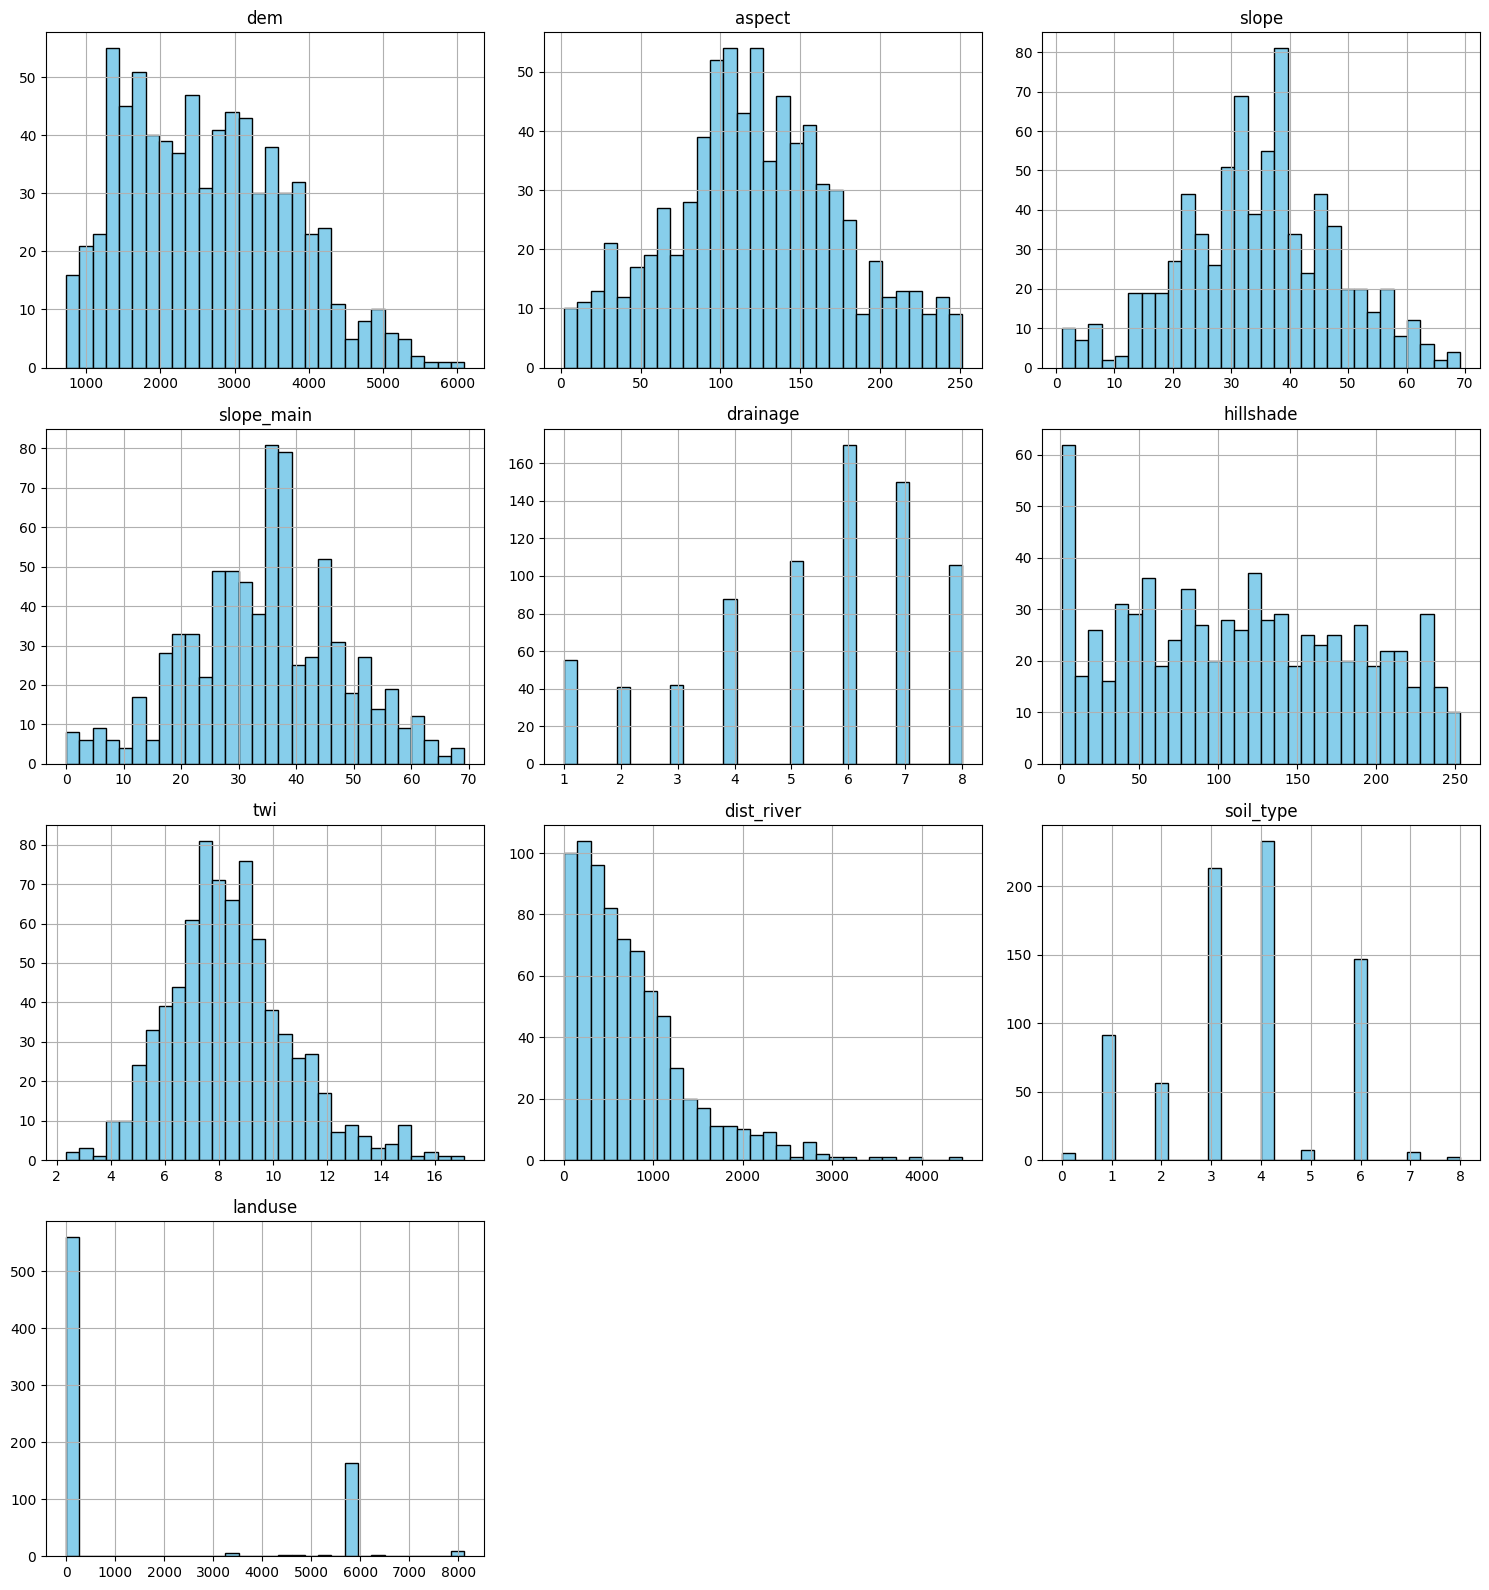

In [8]:
feature_df = df.drop(columns=['x', 'y', 'label'], errors='ignore').select_dtypes(include=[np.number])

n_features = feature_df.shape[1]
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

feature_df.hist(ax=axes[:n_features], bins=30, color='skyblue', edgecolor='black')

# Hide any unused subplot axes when feature count is not a multiple of ncols.
for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 3. Coordinate Point Validation
Verify that the extracted feature values at coordinates perfectly match the source rasters, proving predictions are not 'just for show'.

In [9]:

with open('feature_metadata.json') as f:
    meta = json.load(f)

print(f"Features trained on: {meta['features']}")

sample = df.sample(1).iloc[0]
val_x, val_y = sample['x'], sample['y']
print(f"Testing real sample at X: {val_x}, Y: {val_y}\n")

from rasterio.transform import rowcol
with rasterio.open(meta['raster_files']['slope']) as src:
    row, col = rowcol(src.transform, val_x, val_y)
    actual_slope = src.read(1)[row, col]
    
print(f"Value in training CSV: {sample['slope']}")
print(f"Value directly from TIF: {actual_slope}")
print("MATCH!" if np.isclose(sample['slope'], actual_slope) else "MISMATCH")


Features trained on: ['dem', 'aspect', 'slope', 'slope_main', 'drainage', 'hillshade', 'twi', 'dist_river', 'soil_type', 'landuse']
Testing real sample at X: 354803.97865999327, Y: 3089789.0394101194

Value in training CSV: 26.058134
Value directly from TIF: 26.058134078979492
MATCH!
